# Notebook 03: Model A (Structural) — YOLO Data Preparation

**Objective:** Convert the WebUI Balanced 7K desktop dataset (from Notebook 02) into YOLO format for training a structural UI element detector (YOLOv8m).

**Input:** 20-class manifests from Notebook 02 (train/val/test splits)  
**Output:** YOLO-formatted dataset with 10 structural classes (IDs 0-9)

**Key Steps:**
1. Load manifests and filter to 10 structural classes
2. Clip bounding boxes to viewport boundaries
3. Convert to YOLO normalized format (`class_id x_center y_center width height`)
4. Copy images and write label files
5. Generate `data_model_a.yaml`
6. Validate and visualize

In [1]:
# ============================================================
# IMPORTS & GPU CHECK
# ============================================================
import json
import gzip
import shutil
import gc
import os
import time
from pathlib import Path
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from PIL import Image, ImageDraw
import yaml
import torch

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# GPU Check
print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM:            {vram:.1f} GB")
    print(f"CUDA version:    {torch.version.cuda}")
else:
    print("WARNING: No GPU detected. Training will require GPU.")
print(f"NumPy:           {np.__version__}")
print(f"Pandas:          {pd.__version__}")

ENVIRONMENT CHECK
PyTorch version: 2.5.1+cu121
CUDA available:  True
GPU:             NVIDIA GeForce RTX 3050 Laptop GPU
VRAM:            4.0 GB
CUDA version:    12.1
NumPy:           2.4.2
Pandas:          3.0.0


## 2. Directory Paths

In [2]:
# ============================================================
# DIRECTORY PATHS (all path definitions in this cell only)
# ============================================================

# --- Input paths ---
DATASET_ROOT = Path(r'C:\WebUIDetection\balanced_7k')
NB02_OUTPUT  = Path(r'C:\WebUIDetection\Models and outputs\Outputs\02_notebook')

# --- Output paths ---
OUTPUT_DIR = Path(r'C:\WebUIDetection\Models and outputs\Outputs\03_notebook')
MODEL_DIR  = Path(r'C:\WebUIDetection\Models and outputs\Models\03_notebook')
YOLO_DIR   = OUTPUT_DIR / 'yolo_model_a'
VIS_DIR    = OUTPUT_DIR / 'visualizations'

# --- Create directory structure ---
for d in [OUTPUT_DIR, MODEL_DIR, VIS_DIR,
          YOLO_DIR / 'images' / 'train',
          YOLO_DIR / 'images' / 'val',
          YOLO_DIR / 'images' / 'test',
          YOLO_DIR / 'labels' / 'train',
          YOLO_DIR / 'labels' / 'val',
          YOLO_DIR / 'labels' / 'test']:
    d.mkdir(parents=True, exist_ok=True)

# Print summary
print("=" * 60)
print("DIRECTORY PATHS")
print("=" * 60)
print(f"Dataset root:     {DATASET_ROOT}")
print(f"NB02 outputs:     {NB02_OUTPUT}")
print(f"Output dir:       {OUTPUT_DIR}")
print(f"Model dir:        {MODEL_DIR}")
print(f"YOLO dir:         {YOLO_DIR}")
print(f"Visualizations:   {VIS_DIR}")
print()
print("YOLO directory structure:")
for split in ['train', 'val', 'test']:
    img_dir = YOLO_DIR / 'images' / split
    lbl_dir = YOLO_DIR / 'labels' / split
    print(f"  images/{split}/  -> {img_dir}")
    print(f"  labels/{split}/  -> {lbl_dir}")

DIRECTORY PATHS
Dataset root:     C:\WebUIDetection\balanced_7k
NB02 outputs:     C:\WebUIDetection\Models and outputs\Outputs\02_notebook
Output dir:       C:\WebUIDetection\Models and outputs\Outputs\03_notebook
Model dir:        C:\WebUIDetection\Models and outputs\Models\03_notebook
YOLO dir:         C:\WebUIDetection\Models and outputs\Outputs\03_notebook\yolo_model_a
Visualizations:   C:\WebUIDetection\Models and outputs\Outputs\03_notebook\visualizations

YOLO directory structure:
  images/train/  -> C:\WebUIDetection\Models and outputs\Outputs\03_notebook\yolo_model_a\images\train
  labels/train/  -> C:\WebUIDetection\Models and outputs\Outputs\03_notebook\yolo_model_a\labels\train
  images/val/  -> C:\WebUIDetection\Models and outputs\Outputs\03_notebook\yolo_model_a\images\val
  labels/val/  -> C:\WebUIDetection\Models and outputs\Outputs\03_notebook\yolo_model_a\labels\val
  images/test/  -> C:\WebUIDetection\Models and outputs\Outputs\03_notebook\yolo_model_a\images\test
  

## 3. Load Notebook 02 Artifacts & Configuration

In [3]:
# ============================================================
# LOAD CLASS MAPPING & SPLITS FROM NOTEBOOK 02
# ============================================================

# --- Load 10-class structural mapping ---
with open(NB02_OUTPUT / 'class_mapping_top10.json', 'r') as f:
    class_mapping = json.load(f)

STRUCTURAL_CLASSES = class_mapping['top_10_classes']       # ['none', 'StaticText', ...]
STRUCTURAL_ROLES   = set(STRUCTURAL_CLASSES)               # set for O(1) lookup
ROLE_TO_ID         = class_mapping['class_to_id']          # {'none': 0, 'StaticText': 1, ...}
ID_TO_ROLE         = {int(k): v for k, v in class_mapping['id_to_class'].items()}
NUM_CLASSES        = class_mapping['num_classes']           # 10

# --- Viewport resolution map (parsed from config names) ---
CONFIG_RESOLUTIONS = {
    'default_1280-720':  (1280, 720),
    'default_1366-768':  (1366, 768),
    'default_1536-864':  (1536, 864),
    'default_1920-1080': (1920, 1080),
}
DESKTOP_CONFIGS = list(CONFIG_RESOLUTIONS.keys())

# --- Minimum bbox size after clipping (pixels) ---
MIN_BBOX_PX = 2

# --- Load train/val/test sample splits ---
with open(NB02_OUTPUT / 'splits' / 'train_samples.json', 'r') as f:
    train_sample_ids = json.load(f)
with open(NB02_OUTPUT / 'splits' / 'val_samples.json', 'r') as f:
    val_sample_ids = json.load(f)
with open(NB02_OUTPUT / 'splits' / 'test_samples.json', 'r') as f:
    test_sample_ids = json.load(f)

# --- Print configuration summary ---
print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"Structural classes ({NUM_CLASSES}):")
for cid, role in sorted(ID_TO_ROLE.items()):
    print(f"  {cid}: {role}")
print(f"\nDesktop configurations ({len(DESKTOP_CONFIGS)}):")
for cfg, res in CONFIG_RESOLUTIONS.items():
    print(f"  {cfg} -> {res[0]}x{res[1]}")
print(f"\nMin bbox size after clipping: {MIN_BBOX_PX} px")
print(f"\nSplits loaded:")
print(f"  Train samples: {len(train_sample_ids):,}")
print(f"  Val samples:   {len(val_sample_ids):,}")
print(f"  Test samples:  {len(test_sample_ids):,}")
print(f"  Total:         {len(train_sample_ids) + len(val_sample_ids) + len(test_sample_ids):,}")
print(f"\nExpected screenshots:")
print(f"  Train: {len(train_sample_ids) * 4:,}")
print(f"  Val:   {len(val_sample_ids) * 4:,}")
print(f"  Test:  {len(test_sample_ids) * 4:,}")

# --- Verify manifest files exist ---
for split in ['train', 'val', 'test']:
    manifest_path = NB02_OUTPUT / 'manifests' / f'{split}_manifest.json'
    size_mb = manifest_path.stat().st_size / (1024 * 1024)
    print(f"\n  {split}_manifest.json: {size_mb:.1f} MB")

CONFIGURATION
Structural classes (9):
  0: none
  1: StaticText
  2: link
  3: generic
  4: listitem
  5: paragraph
  6: heading
  7: img
  8: list

Desktop configurations (4):
  default_1280-720 -> 1280x720
  default_1366-768 -> 1366x768
  default_1536-864 -> 1536x864
  default_1920-1080 -> 1920x1080

Min bbox size after clipping: 2 px

Splits loaded:
  Train samples: 4,899
  Val samples:   1,050
  Test samples:  1,050
  Total:         6,999

Expected screenshots:
  Train: 19,596
  Val:   4,200
  Test:  4,200

  train_manifest.json: 298.1 MB

  val_manifest.json: 62.1 MB

  test_manifest.json: 62.5 MB


## 4. Conversion Functions

Helper functions for:
- **Viewport clipping** — discard off-screen elements, clip partially visible ones
- **YOLO format conversion** — normalize to `class_id x_center y_center width height` (0-1)
- **Label file writing** — one `.txt` per image

In [4]:
# ============================================================
# CONVERSION HELPER FUNCTIONS
# ============================================================

def clip_bbox_to_viewport(
    bbox: Dict, img_w: int, img_h: int
) -> Optional[Tuple[float, float, float, float, bool]]:
    """
    Clip a bounding box to viewport boundaries.
    
    Args:
        bbox:  dict with 'x', 'y', 'width', 'height' (pixel coords)
        img_w: viewport width in pixels
        img_h: viewport height in pixels
    
    Returns:
        (x, y, w, h, was_clipped) or None if fully off-screen / too small.
        x, y are top-left corner of the clipped box.
    """
    x = float(bbox.get('x', 0))
    y = float(bbox.get('y', 0))
    w = float(bbox.get('width', 0))
    h = float(bbox.get('height', 0))
    
    # Skip invalid / zero-area bboxes
    if w <= 0 or h <= 0:
        return None
    
    # Original corners
    x1, y1 = x, y
    x2, y2 = x + w, y + h
    
    # Fully outside viewport?
    if x1 >= img_w or y1 >= img_h or x2 <= 0 or y2 <= 0:
        return None
    
    # Clip to viewport
    cx1 = max(0.0, x1)
    cy1 = max(0.0, y1)
    cx2 = min(float(img_w), x2)
    cy2 = min(float(img_h), y2)
    
    was_clipped = (cx1 != x1 or cy1 != y1 or cx2 != x2 or cy2 != y2)
    
    cw = cx2 - cx1
    ch = cy2 - cy1
    
    # Discard if too small after clipping
    if cw < MIN_BBOX_PX or ch < MIN_BBOX_PX:
        return None
    
    return (cx1, cy1, cw, ch, was_clipped)


def bbox_to_yolo(
    x: float, y: float, w: float, h: float, img_w: int, img_h: int
) -> Tuple[float, float, float, float]:
    """
    Convert pixel bbox (top-left x, y, w, h) to YOLO normalized format.
    
    Returns:
        (x_center, y_center, width, height) all in [0, 1].
    """
    x_center = (x + w / 2.0) / img_w
    y_center = (y + h / 2.0) / img_h
    w_norm   = w / img_w
    h_norm   = h / img_h
    
    # Clamp to [0, 1]
    x_center = max(0.0, min(1.0, x_center))
    y_center = max(0.0, min(1.0, y_center))
    w_norm   = max(0.0, min(1.0, w_norm))
    h_norm   = max(0.0, min(1.0, h_norm))
    
    return x_center, y_center, w_norm, h_norm


def write_yolo_label(label_path: Path, lines: List[str]) -> None:
    """Write YOLO label file. Empty file = negative sample."""
    with open(label_path, 'w') as f:
        if lines:
            f.write('\n'.join(lines) + '\n')


def process_split(
    split_name: str,
    manifest_path: Path,
    img_out_dir: Path,
    lbl_out_dir: Path,
    structural_roles: set,
    role_to_id: Dict[str, int],
    config_resolutions: Dict[str, Tuple[int, int]],
) -> Tuple[Dict, Counter]:
    """
    Load a manifest, filter to structural classes, clip to viewport,
    convert to YOLO format, copy images, and write label files.
    
    Returns:
        (stats_dict, class_counter)
    """
    # Load manifest
    print(f"\n{'='*60}")
    print(f"PROCESSING {split_name.upper()} SPLIT")
    print(f"{'='*60}")
    print(f"Loading {manifest_path.name} ...")
    t0 = time.time()
    
    with open(manifest_path, 'r') as f:
        manifest = json.load(f)
    
    load_time = time.time() - t0
    print(f"Loaded {len(manifest):,} entries in {load_time:.1f}s")
    
    # Statistics accumulators
    stats = {
        'images': 0,
        'labels': 0,
        'total_yolo_bboxes': 0,
        'empty_labels': 0,
        'structural_bboxes_before_clip': 0,
        'clipped_bboxes': 0,
        'discarded_offscreen': 0,
        'discarded_too_small': 0,
        'non_structural_skipped': 0,
    }
    class_counts = Counter()
    
    t1 = time.time()
    for entry in tqdm(manifest, desc=f'{split_name.capitalize()}'):
        sample_id = entry['sample_id']
        config    = entry['config']
        img_w, img_h = config_resolutions[config]
        
        # File naming: {sample_id}_{config}.webp / .txt
        fname   = f"{sample_id}_{config}"
        img_src = DATASET_ROOT / sample_id / f"{config}-screenshot.webp"
        img_dst = img_out_dir / f"{fname}.webp"
        lbl_dst = lbl_out_dir / f"{fname}.txt"
        
        # Copy image (skip if already exists for idempotency)
        if not img_dst.exists():
            shutil.copy2(img_src, img_dst)
        stats['images'] += 1
        
        # Extract annotation data
        bboxes   = entry['annotation_data']['bboxes']
        elem_map = entry['annotation_data']['element_class_map']
        
        # Process bounding boxes
        yolo_lines = []
        for elem_id, bbox in bboxes.items():
            # Get ARIA role for this element
            role = elem_map.get(elem_id, 'unknown')
            
            # Filter: keep only structural classes
            if role not in structural_roles:
                stats['non_structural_skipped'] += 1
                continue
            
            stats['structural_bboxes_before_clip'] += 1
            
            # Clip to viewport
            clipped = clip_bbox_to_viewport(bbox, img_w, img_h)
            if clipped is None:
                # Determine reason for discard
                x = float(bbox.get('x', 0))
                y = float(bbox.get('y', 0))
                w = float(bbox.get('width', 0))
                h = float(bbox.get('height', 0))
                if w <= 0 or h <= 0:
                    stats['discarded_too_small'] += 1
                elif x >= img_w or y >= img_h or (x + w) <= 0 or (y + h) <= 0:
                    stats['discarded_offscreen'] += 1
                else:
                    stats['discarded_too_small'] += 1  # clipped below MIN_BBOX_PX
                continue
            
            cx, cy, cw, ch, was_clipped = clipped
            if was_clipped:
                stats['clipped_bboxes'] += 1
            
            # Convert to YOLO normalized format
            class_id = role_to_id[role]
            xc, yc, wn, hn = bbox_to_yolo(cx, cy, cw, ch, img_w, img_h)
            yolo_lines.append(f"{class_id} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")
            class_counts[class_id] += 1
        
        # Write label file
        write_yolo_label(lbl_dst, yolo_lines)
        stats['labels'] += 1
        stats['total_yolo_bboxes'] += len(yolo_lines)
        if len(yolo_lines) == 0:
            stats['empty_labels'] += 1
    
    proc_time = time.time() - t1
    
    # Free manifest memory
    del manifest
    gc.collect()
    
    # Print summary
    print(f"\n{split_name.upper()} COMPLETE ({proc_time:.0f}s)")
    print(f"  Images copied:       {stats['images']:,}")
    print(f"  Labels written:      {stats['labels']:,}")
    print(f"  Total YOLO bboxes:   {stats['total_yolo_bboxes']:,}")
    avg = stats['total_yolo_bboxes'] / max(stats['images'], 1)
    print(f"  Avg bboxes/image:    {avg:.1f}")
    print(f"  Empty labels:        {stats['empty_labels']}")
    print(f"  Non-structural skip: {stats['non_structural_skipped']:,}")
    print(f"  Structural (pre-clip): {stats['structural_bboxes_before_clip']:,}")
    print(f"  Viewport-clipped:    {stats['clipped_bboxes']:,}")
    print(f"  Discarded off-screen:{stats['discarded_offscreen']:,}")
    print(f"  Discarded too small: {stats['discarded_too_small']:,}")
    
    return stats, class_counts


print("Conversion functions defined successfully.")
print(f"  clip_bbox_to_viewport()  - clips bbox to viewport, returns None if invalid")
print(f"  bbox_to_yolo()           - converts pixel coords to YOLO normalized format")
print(f"  write_yolo_label()       - writes .txt label file")
print(f"  process_split()          - end-to-end split processing (load → copy → convert → write)")

Conversion functions defined successfully.
  clip_bbox_to_viewport()  - clips bbox to viewport, returns None if invalid
  bbox_to_yolo()           - converts pixel coords to YOLO normalized format
  write_yolo_label()       - writes .txt label file
  process_split()          - end-to-end split processing (load → copy → convert → write)


## 5. Process Train Split

Load the train manifest (~285 MB, 19,596 entries), filter to 10 structural classes, clip bboxes to viewport, convert to YOLO format, copy images, and write label files.

**This cell takes ~15-25 minutes** (mainly due to file copying).

In [5]:
# ============================================================
# PROCESS TRAIN SPLIT
# ============================================================

train_stats, train_class_counts = process_split(
    split_name='train',
    manifest_path=NB02_OUTPUT / 'manifests' / 'train_manifest.json',
    img_out_dir=YOLO_DIR / 'images' / 'train',
    lbl_out_dir=YOLO_DIR / 'labels' / 'train',
    structural_roles=STRUCTURAL_ROLES,
    role_to_id=ROLE_TO_ID,
    config_resolutions=CONFIG_RESOLUTIONS,
)

# Show class distribution for train
print(f"\nTrain class distribution:")
for cid in sorted(train_class_counts.keys()):
    role = ID_TO_ROLE[cid]
    count = train_class_counts[cid]
    print(f"  {cid:2d} ({role:12s}): {count:>10,}")


PROCESSING TRAIN SPLIT
Loading train_manifest.json ...
Loaded 19,596 entries in 4.7s


Train: 100%|██████████| 19596/19596 [04:10<00:00, 78.18it/s] 



TRAIN COMPLETE (251s)
  Images copied:       19,596
  Labels written:      19,596
  Total YOLO bboxes:   838,854
  Avg bboxes/image:    42.8
  Empty labels:        0
  Non-structural skip: 140,289
  Structural (pre-clip): 1,754,640
  Viewport-clipped:    80,079
  Discarded off-screen:839,268
  Discarded too small: 76,518

Train class distribution:
   0 (none        ):    151,183
   1 (StaticText  ):    282,342
   2 (link        ):    135,296
   3 (generic     ):     86,288
   4 (listitem    ):     80,682
   5 (paragraph   ):     38,541
   6 (heading     ):     33,932
   7 (img         ):     14,792
   8 (list        ):     15,798


## 6. Process Val & Test Splits

Same process for validation (~62 MB, 4,200 entries) and test (~62 MB, 4,200 entries) splits.

In [6]:
# ============================================================
# PROCESS VAL & TEST SPLITS
# ============================================================

# --- Validation split ---
val_stats, val_class_counts = process_split(
    split_name='val',
    manifest_path=NB02_OUTPUT / 'manifests' / 'val_manifest.json',
    img_out_dir=YOLO_DIR / 'images' / 'val',
    lbl_out_dir=YOLO_DIR / 'labels' / 'val',
    structural_roles=STRUCTURAL_ROLES,
    role_to_id=ROLE_TO_ID,
    config_resolutions=CONFIG_RESOLUTIONS,
)

# --- Test split ---
test_stats, test_class_counts = process_split(
    split_name='test',
    manifest_path=NB02_OUTPUT / 'manifests' / 'test_manifest.json',
    img_out_dir=YOLO_DIR / 'images' / 'test',
    lbl_out_dir=YOLO_DIR / 'labels' / 'test',
    structural_roles=STRUCTURAL_ROLES,
    role_to_id=ROLE_TO_ID,
    config_resolutions=CONFIG_RESOLUTIONS,
)

# --- Combined summary ---
all_split_stats = {'train': train_stats, 'val': val_stats, 'test': test_stats}
all_class_counts = {'train': train_class_counts, 'val': val_class_counts, 'test': test_class_counts}

print(f"\n{'='*60}")
print("ALL SPLITS COMPLETE")
print(f"{'='*60}")

total_images = sum(s['images'] for s in all_split_stats.values())
total_bboxes = sum(s['total_yolo_bboxes'] for s in all_split_stats.values())
total_empty  = sum(s['empty_labels'] for s in all_split_stats.values())

print(f"Total images:     {total_images:,}")
print(f"Total YOLO bboxes:{total_bboxes:,}")
print(f"Total empty labels:{total_empty:,}")
print(f"Overall avg bboxes/image: {total_bboxes / max(total_images, 1):.1f}")

for split_name, stats in all_split_stats.items():
    pct = stats['images'] / max(total_images, 1) * 100
    print(f"  {split_name:5s}: {stats['images']:>6,} images, "
          f"{stats['total_yolo_bboxes']:>10,} bboxes ({pct:.1f}%)")


PROCESSING VAL SPLIT
Loading val_manifest.json ...
Loaded 4,200 entries in 1.0s


Val: 100%|██████████| 4200/4200 [00:51<00:00, 81.24it/s] 



VAL COMPLETE (52s)
  Images copied:       4,200
  Labels written:      4,200
  Total YOLO bboxes:   174,416
  Avg bboxes/image:    41.5
  Empty labels:        0
  Non-structural skip: 27,611
  Structural (pre-clip): 364,406
  Viewport-clipped:    16,622
  Discarded off-screen:173,647
  Discarded too small: 16,343

PROCESSING TEST SPLIT
Loading test_manifest.json ...
Loaded 4,200 entries in 1.0s


Test: 100%|██████████| 4200/4200 [00:49<00:00, 84.27it/s] 


TEST COMPLETE (50s)
  Images copied:       4,200
  Labels written:      4,200
  Total YOLO bboxes:   183,340
  Avg bboxes/image:    43.7
  Empty labels:        0
  Non-structural skip: 27,374
  Structural (pre-clip): 368,698
  Viewport-clipped:    17,629
  Discarded off-screen:168,741
  Discarded too small: 16,617

ALL SPLITS COMPLETE
Total images:     27,996
Total YOLO bboxes:1,196,610
Total empty labels:0
Overall avg bboxes/image: 42.7
  train: 19,596 images,    838,854 bboxes (70.0%)
  val  :  4,200 images,    174,416 bboxes (15.0%)
  test :  4,200 images,    183,340 bboxes (15.0%)


## 7. Generate `data_model_a.yaml`

YOLO training configuration file with dataset paths and class names. A copy is also placed in `Models/03_notebook/` for the training notebook.

In [7]:
# ============================================================
# GENERATE data_model_a.yaml
# ============================================================

data_yaml = {
    'path': str(YOLO_DIR.resolve()),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc':    NUM_CLASSES,
    'names': STRUCTURAL_CLASSES,
}

# Write to YOLO directory
yaml_path = YOLO_DIR / 'data_model_a.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

# Copy to Models directory for training notebook convenience
yaml_model_path = MODEL_DIR / 'data_model_a.yaml'
shutil.copy2(yaml_path, yaml_model_path)

# Display contents
print("=" * 60)
print("data_model_a.yaml")
print("=" * 60)
with open(yaml_path, 'r') as f:
    print(f.read())
print(f"Saved to: {yaml_path}")
print(f"Copied to: {yaml_model_path}")

data_model_a.yaml
path: C:\WebUIDetection\Models and outputs\Outputs\03_notebook\yolo_model_a
train: images/train
val: images/val
test: images/test
nc: 9
names:
- none
- StaticText
- link
- generic
- listitem
- paragraph
- heading
- img
- list

Saved to: C:\WebUIDetection\Models and outputs\Outputs\03_notebook\yolo_model_a\data_model_a.yaml
Copied to: C:\WebUIDetection\Models and outputs\Models\03_notebook\data_model_a.yaml


## 8. Validation: Label Integrity

Scan all label files to verify:
- Every label line has exactly 5 fields: `class_id x_center y_center width height`
- Class IDs are in `{0, 1, ..., 9}`
- All coordinates are in `[0.0, 1.0]`
- Every image has a matching label file and vice versa

In [8]:
# ============================================================
# VALIDATION: LABEL INTEGRITY
# ============================================================

print("=" * 60)
print("LABEL INTEGRITY VALIDATION")
print("=" * 60)

valid_class_ids = set(range(NUM_CLASSES))  # {0, 1, ..., 9}
validation_results = {}

for split in ['train', 'val', 'test']:
    img_dir = YOLO_DIR / 'images' / split
    lbl_dir = YOLO_DIR / 'labels' / split
    
    img_files = set(p.stem for p in img_dir.glob('*.webp'))
    lbl_files = set(p.stem for p in lbl_dir.glob('*.txt'))
    
    # Cross-check: images <-> labels
    imgs_without_labels = img_files - lbl_files
    labels_without_imgs = lbl_files - img_files
    
    # Validate label content
    total_lines = 0
    empty_files = 0
    invalid_lines = []
    class_id_errors = 0
    coord_errors = 0
    field_errors = 0
    
    for lbl_path in sorted(lbl_dir.glob('*.txt')):
        with open(lbl_path, 'r') as f:
            lines = f.read().strip().split('\n')
        
        if lines == ['']:  # empty file
            empty_files += 1
            continue
        
        for line_num, line in enumerate(lines, 1):
            total_lines += 1
            parts = line.strip().split()
            
            # Check field count
            if len(parts) != 5:
                field_errors += 1
                if len(invalid_lines) < 10:
                    invalid_lines.append(f"{lbl_path.name}:{line_num} - {len(parts)} fields")
                continue
            
            try:
                cls_id = int(parts[0])
                coords = [float(p) for p in parts[1:]]
            except ValueError:
                field_errors += 1
                if len(invalid_lines) < 10:
                    invalid_lines.append(f"{lbl_path.name}:{line_num} - parse error")
                continue
            
            # Check class ID
            if cls_id not in valid_class_ids:
                class_id_errors += 1
                if len(invalid_lines) < 10:
                    invalid_lines.append(f"{lbl_path.name}:{line_num} - class {cls_id}")
            
            # Check coordinates in [0, 1]
            for i, c in enumerate(coords):
                if c < 0.0 or c > 1.0:
                    coord_errors += 1
                    if len(invalid_lines) < 10:
                        invalid_lines.append(f"{lbl_path.name}:{line_num} - coord[{i}]={c:.4f}")
                    break
    
    # Store results
    result = {
        'images': len(img_files),
        'labels': len(lbl_files),
        'matched': len(img_files & lbl_files),
        'imgs_without_labels': len(imgs_without_labels),
        'labels_without_imgs': len(labels_without_imgs),
        'total_lines': total_lines,
        'empty_files': empty_files,
        'field_errors': field_errors,
        'class_id_errors': class_id_errors,
        'coord_errors': coord_errors,
    }
    validation_results[split] = result
    
    # Print per-split results
    status = "PASS" if (result['field_errors'] + result['class_id_errors'] + 
                        result['coord_errors'] + result['imgs_without_labels'] + 
                        result['labels_without_imgs']) == 0 else "FAIL"
    
    print(f"\n--- {split.upper()} [{status}] ---")
    print(f"  Images:              {result['images']:,}")
    print(f"  Labels:              {result['labels']:,}")
    print(f"  Matched pairs:       {result['matched']:,}")
    print(f"  Images w/o labels:   {result['imgs_without_labels']}")
    print(f"  Labels w/o images:   {result['labels_without_imgs']}")
    print(f"  Total bbox lines:    {result['total_lines']:,}")
    print(f"  Empty label files:   {result['empty_files']}")
    print(f"  Field errors:        {result['field_errors']}")
    print(f"  Class ID errors:     {result['class_id_errors']}")
    print(f"  Coordinate errors:   {result['coord_errors']}")
    
    if invalid_lines:
        print(f"  Sample errors:")
        for err in invalid_lines[:5]:
            print(f"    {err}")

# Overall verdict
all_pass = all(
    (r['field_errors'] + r['class_id_errors'] + r['coord_errors'] + 
     r['imgs_without_labels'] + r['labels_without_imgs']) == 0
    for r in validation_results.values()
)
print(f"\n{'='*60}")
print(f"OVERALL VALIDATION: {'PASS ✓' if all_pass else 'FAIL ✗'}")
print(f"{'='*60}")

LABEL INTEGRITY VALIDATION

--- TRAIN [PASS] ---
  Images:              19,596
  Labels:              19,596
  Matched pairs:       19,596
  Images w/o labels:   0
  Labels w/o images:   0
  Total bbox lines:    838,854
  Empty label files:   0
  Field errors:        0
  Class ID errors:     0
  Coordinate errors:   0

--- VAL [PASS] ---
  Images:              4,200
  Labels:              4,200
  Matched pairs:       4,200
  Images w/o labels:   0
  Labels w/o images:   0
  Total bbox lines:    174,416
  Empty label files:   0
  Field errors:        0
  Class ID errors:     0
  Coordinate errors:   0

--- TEST [PASS] ---
  Images:              4,200
  Labels:              4,200
  Matched pairs:       4,200
  Images w/o labels:   0
  Labels w/o images:   0
  Total bbox lines:    183,340
  Empty label files:   0
  Field errors:        0
  Class ID errors:     0
  Coordinate errors:   0

OVERALL VALIDATION: PASS ✓


## 9. Class Distribution Analysis

Verify class counts across all splits and compute imbalance metrics.

CLASS DISTRIBUTION ACROSS SPLITS
 class_id       name  train   val  test  total  train_pct   val_pct  test_pct
        0       none 151183 31650 30019 212852  18.022564 18.146271 16.373405
        1 StaticText 282342 57849 64387 404578  33.658062 33.167255 35.118905
        2       link 135296 27399 29476 192171  16.128671 15.708995 16.077234
        3    generic  86288 18335 19075 123698  10.286415 10.512224 10.404167
        4   listitem  80682 17158 17950 115790   9.618122  9.837400  9.790553
        5  paragraph  38541  7934  8124  54599   4.594482  4.548895  4.431112
        6    heading  33932  7456  7842  49230   4.045042  4.274837  4.277299
        7        img  14792  3259  2887  20938   1.763358  1.868521  1.574670
        8       list  15798  3376  3580  22754   1.883284  1.935602  1.952656

Class imbalance ratio (max/min): 19.3x
Most common:  StaticText (404,578)
Least common: img (20,938)


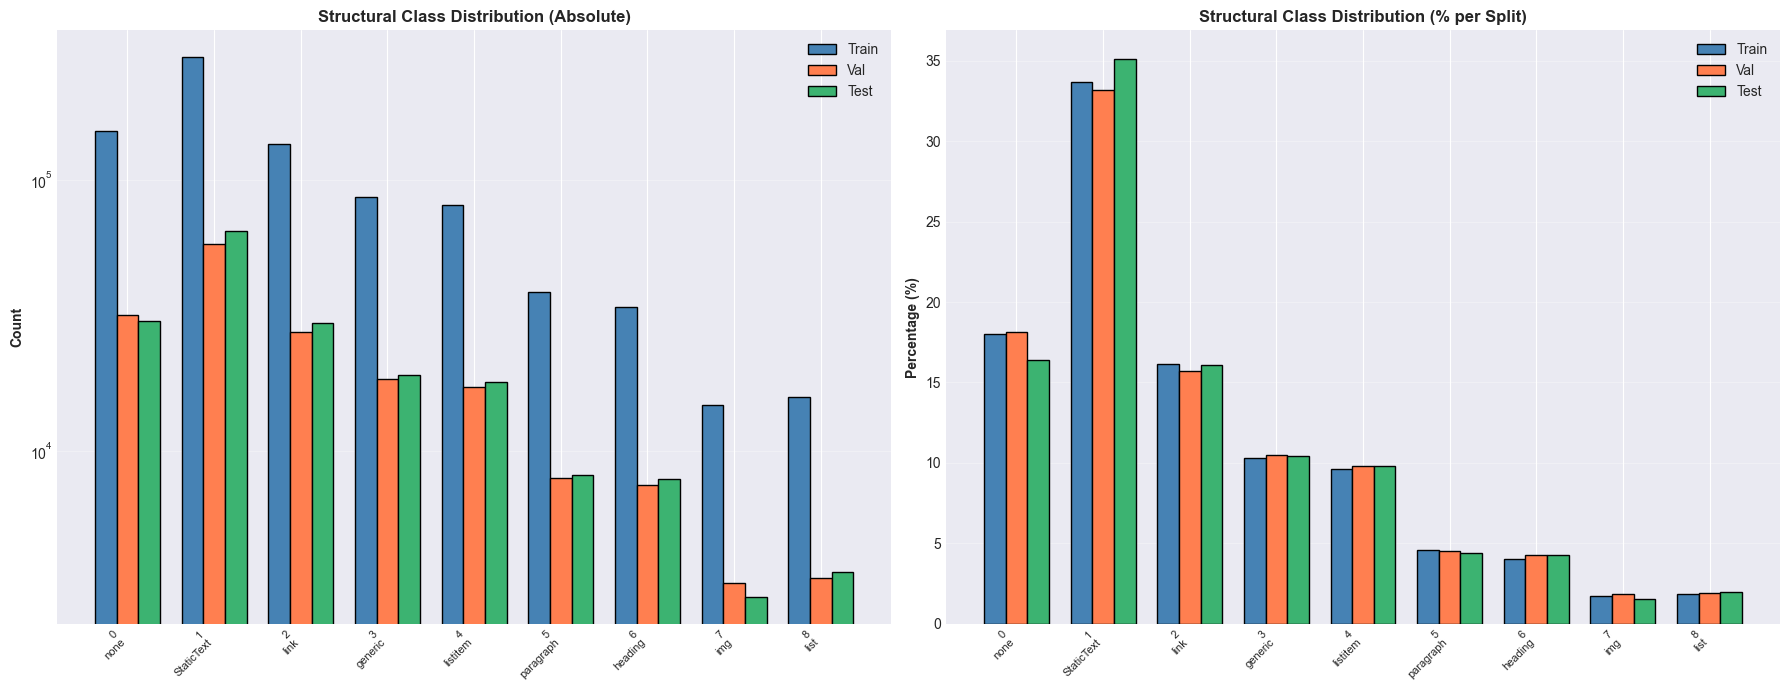


Saved: C:\WebUIDetection\Models and outputs\Outputs\03_notebook\visualizations\structural_class_distribution.png


In [9]:
# ============================================================
# CLASS DISTRIBUTION ANALYSIS + BAR CHART
# ============================================================

print("=" * 60)
print("CLASS DISTRIBUTION ACROSS SPLITS")
print("=" * 60)

# Build combined table
rows = []
for cid in range(NUM_CLASSES):
    role = ID_TO_ROLE[cid]
    tr = train_class_counts.get(cid, 0)
    va = val_class_counts.get(cid, 0)
    te = test_class_counts.get(cid, 0)
    total = tr + va + te
    rows.append({
        'class_id': cid,
        'name': role,
        'train': tr,
        'val': va,
        'test': te,
        'total': total,
    })

dist_df = pd.DataFrame(rows)
dist_df['train_pct'] = dist_df['train'] / dist_df['train'].sum() * 100
dist_df['val_pct']   = dist_df['val']   / dist_df['val'].sum()   * 100
dist_df['test_pct']  = dist_df['test']  / dist_df['test'].sum()  * 100

print(dist_df.to_string(index=False))

# Imbalance ratio
max_count = dist_df['total'].max()
min_count = dist_df['total'].min()
print(f"\nClass imbalance ratio (max/min): {max_count / max(min_count, 1):.1f}x")
print(f"Most common:  {dist_df.loc[dist_df['total'].idxmax(), 'name']} ({max_count:,})")
print(f"Least common: {dist_df.loc[dist_df['total'].idxmin(), 'name']} ({min_count:,})")

# --- Bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Absolute counts
ax1 = axes[0]
x = np.arange(NUM_CLASSES)
width = 0.25
ax1.bar(x - width, dist_df['train'], width, label='Train', color='steelblue', edgecolor='black')
ax1.bar(x,         dist_df['val'],   width, label='Val',   color='coral',     edgecolor='black')
ax1.bar(x + width, dist_df['test'],  width, label='Test',  color='mediumseagreen', edgecolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{cid}\n{ID_TO_ROLE[cid][:10]}" for cid in range(NUM_CLASSES)],
                     rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Count', fontweight='bold')
ax1.set_title('Structural Class Distribution (Absolute)', fontweight='bold')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Percentage per split (shows balance)
ax2 = axes[1]
ax2.bar(x - width, dist_df['train_pct'], width, label='Train', color='steelblue', edgecolor='black')
ax2.bar(x,         dist_df['val_pct'],   width, label='Val',   color='coral',     edgecolor='black')
ax2.bar(x + width, dist_df['test_pct'],  width, label='Test',  color='mediumseagreen', edgecolor='black')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{cid}\n{ID_TO_ROLE[cid][:10]}" for cid in range(NUM_CLASSES)],
                     rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Percentage (%)', fontweight='bold')
ax2.set_title('Structural Class Distribution (% per Split)', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(VIS_DIR / 'structural_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved: {VIS_DIR / 'structural_class_distribution.png'}")

## 10. Visualization: Sample Annotations

Draw YOLO bounding boxes on 6 random training images to visually verify alignment.

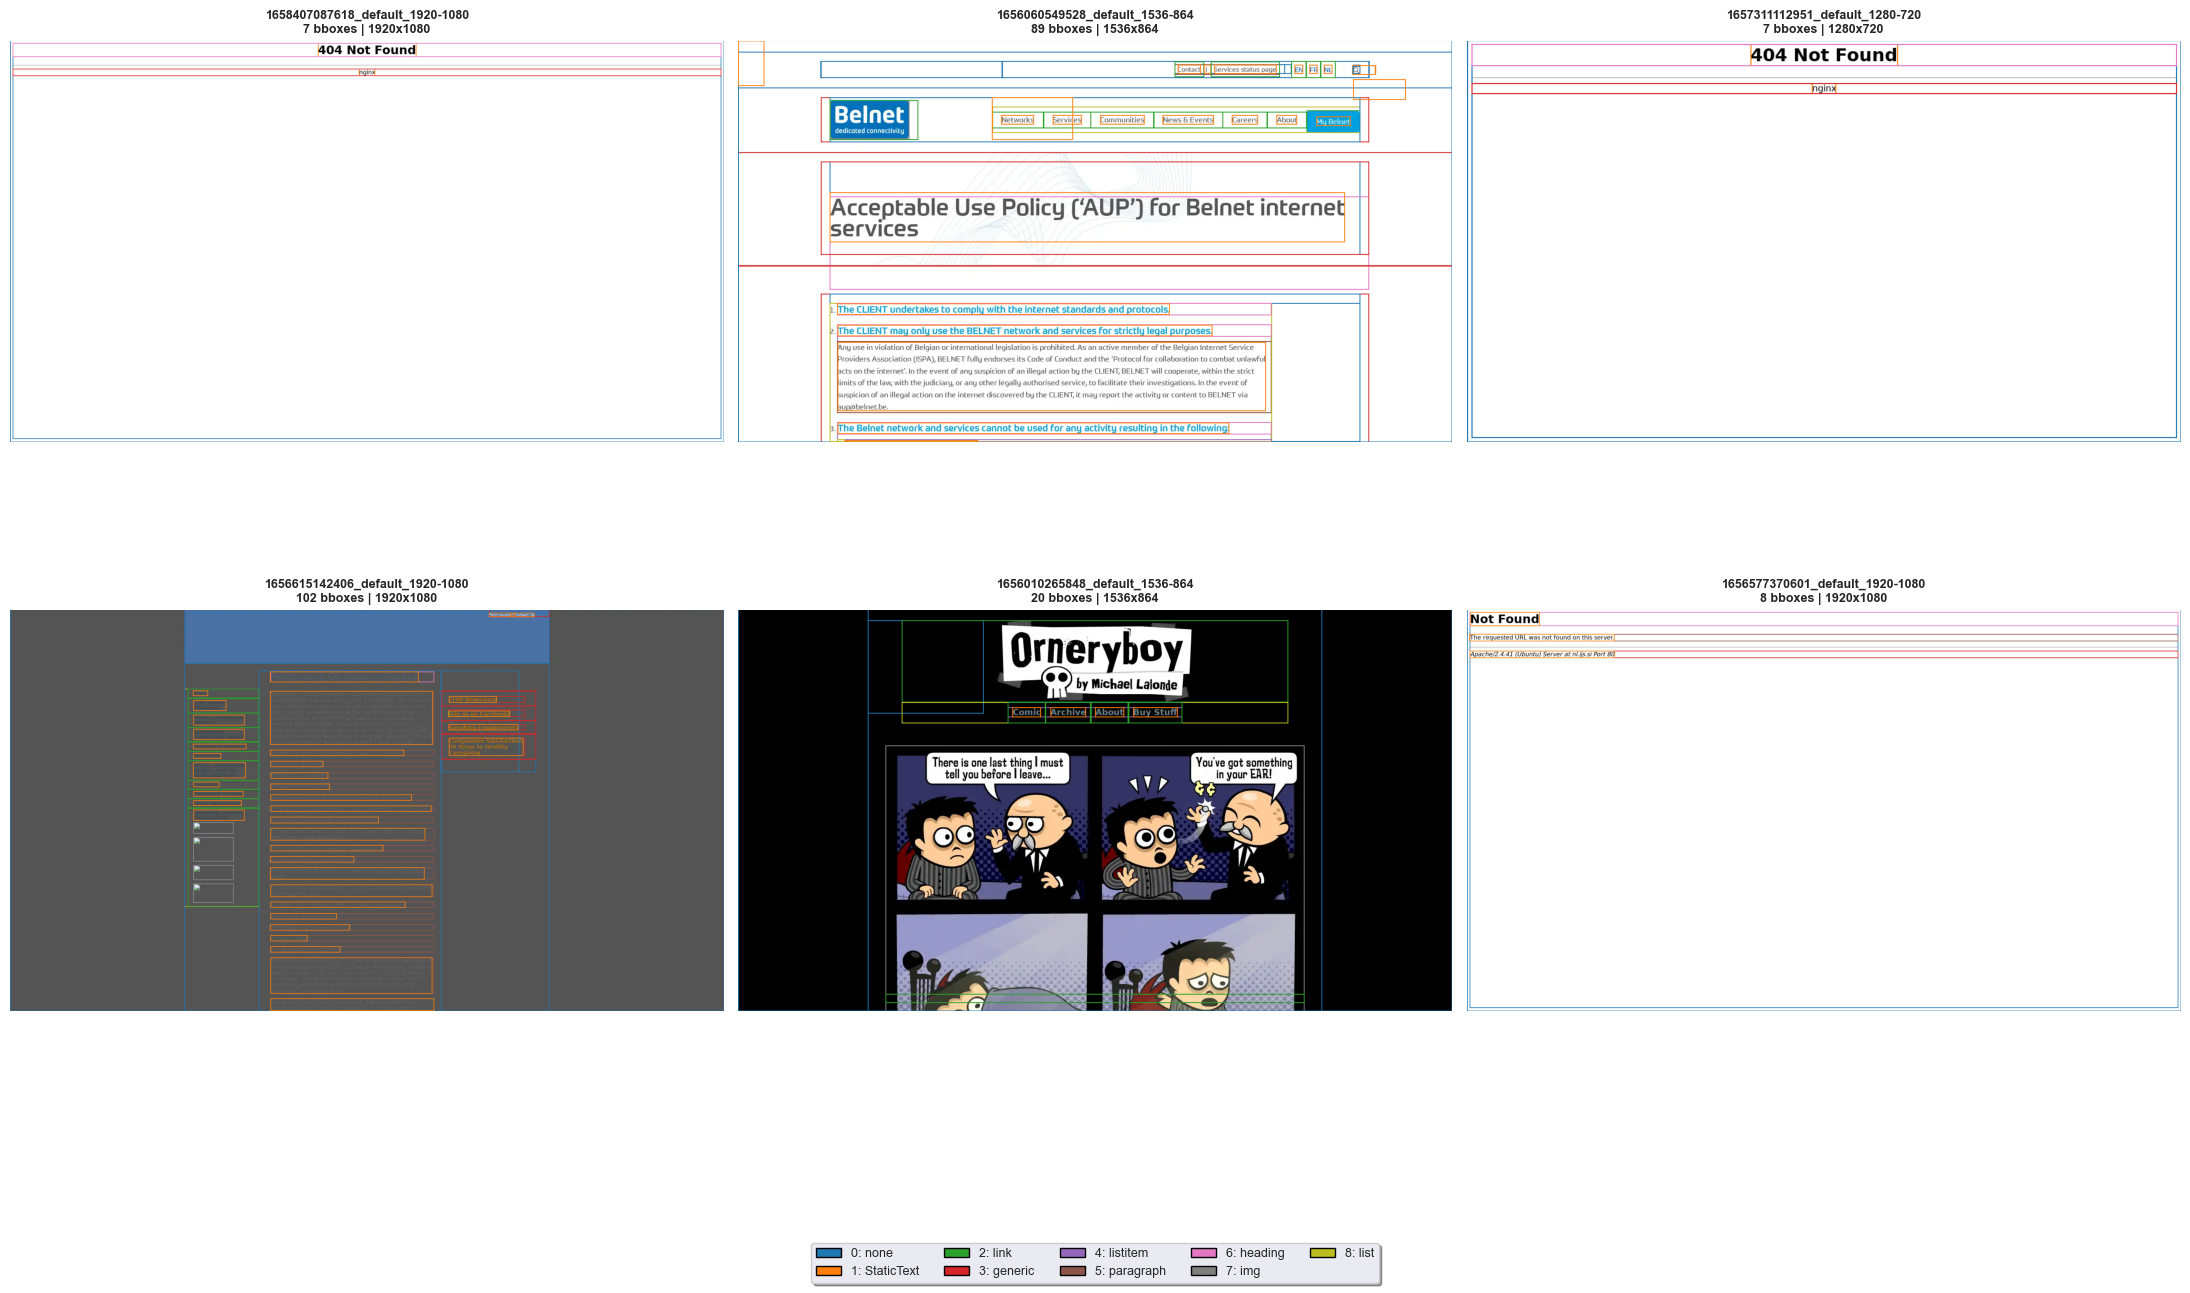

Saved: C:\WebUIDetection\Models and outputs\Outputs\03_notebook\visualizations\sample_yolo_annotations.png


In [10]:
# ============================================================
# VISUALIZATION: SAMPLE ANNOTATIONS (YOLO bboxes on images)
# ============================================================

np.random.seed(42)

# Get list of train images
train_img_dir = YOLO_DIR / 'images' / 'train'
train_lbl_dir = YOLO_DIR / 'labels' / 'train'
train_images = sorted(train_img_dir.glob('*.webp'))

# Pick 6 random samples
sample_indices = np.random.choice(len(train_images), size=min(6, len(train_images)), replace=False)
sample_paths = [train_images[i] for i in sample_indices]

# Color map for 10 classes
cmap = plt.cm.tab10(range(NUM_CLASSES))
colors_rgb = [(int(c[0]*255), int(c[1]*255), int(c[2]*255)) for c in cmap]

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

for idx, img_path in enumerate(sample_paths):
    # Load image
    img = Image.open(img_path).convert('RGB')
    img_w, img_h = img.size
    draw = ImageDraw.Draw(img)
    
    # Load corresponding label
    lbl_path = train_lbl_dir / f"{img_path.stem}.txt"
    bbox_count = 0
    
    if lbl_path.exists():
        with open(lbl_path, 'r') as f:
            lines = f.read().strip().split('\n')
        
        for line in lines:
            if not line.strip():
                continue
            parts = line.strip().split()
            cls_id = int(parts[0])
            xc, yc, wn, hn = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            
            # Denormalize to pixel coordinates
            bw = wn * img_w
            bh = hn * img_h
            x1 = (xc * img_w) - bw / 2
            y1 = (yc * img_h) - bh / 2
            x2 = x1 + bw
            y2 = y1 + bh
            
            color = colors_rgb[cls_id]
            draw.rectangle([x1, y1, x2, y2], outline=color, width=2)
            bbox_count += 1
    
    ax = axes[idx]
    ax.imshow(img)
    ax.set_title(f"{img_path.stem}\n{bbox_count} bboxes | {img_w}x{img_h}", fontsize=9, fontweight='bold')
    ax.axis('off')

# Legend
legend_elements = [mpatches.Patch(facecolor=cmap[i], edgecolor='black',
                                   label=f'{i}: {ID_TO_ROLE[i]}')
                   for i in range(NUM_CLASSES)]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=9,
           frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(VIS_DIR / 'sample_yolo_annotations.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIS_DIR / 'sample_yolo_annotations.png'}")

## 11. Visualization: Bbox Geometry

Analyze normalized bounding box sizes and aspect ratios from a random subset of label files.

Sampled 2000 label files, 89,457 bboxes


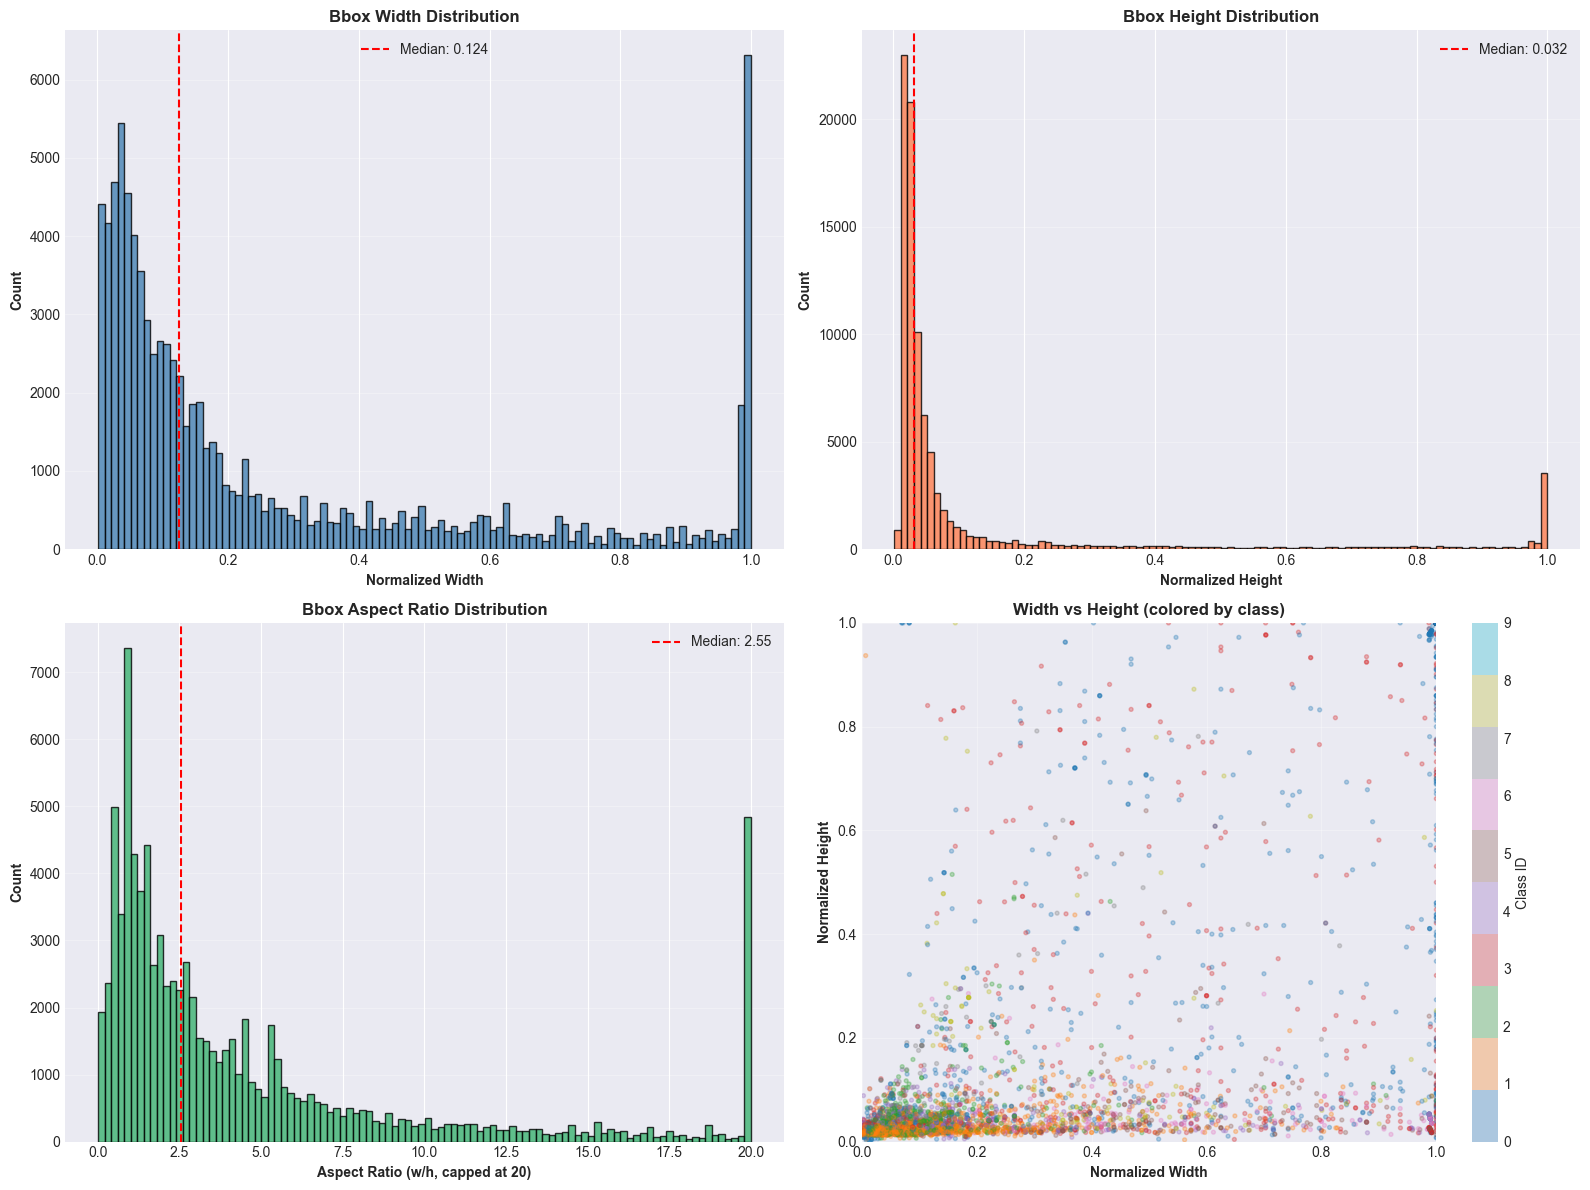


Bbox geometry statistics (89,457 boxes from 2000 images):
  Width  - mean: 0.2749, median: 0.1243, std: 0.3167
  Height - mean: 0.1301, median: 0.0319, std: 0.2512
  Aspect - mean: 5.46, median: 2.55

Saved: C:\WebUIDetection\Models and outputs\Outputs\03_notebook\visualizations\bbox_geometry_structural.png


In [11]:
# ============================================================
# VISUALIZATION: BBOX GEOMETRY (width, height, aspect ratio)
# ============================================================

# Sample ~2000 label files from train
np.random.seed(42)
all_train_labels = sorted((YOLO_DIR / 'labels' / 'train').glob('*.txt'))
sample_size = min(2000, len(all_train_labels))
sampled_labels = [all_train_labels[i] for i in np.random.choice(len(all_train_labels), sample_size, replace=False)]

widths = []
heights = []
aspect_ratios = []
class_ids_geom = []

for lbl_path in sampled_labels:
    with open(lbl_path, 'r') as f:
        content = f.read().strip()
    if not content:
        continue
    for line in content.split('\n'):
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cid = int(parts[0])
        wn, hn = float(parts[3]), float(parts[4])
        if wn > 0 and hn > 0:
            widths.append(wn)
            heights.append(hn)
            aspect_ratios.append(wn / hn)
            class_ids_geom.append(cid)

print(f"Sampled {sample_size} label files, {len(widths):,} bboxes")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Width distribution
ax1 = axes[0, 0]
ax1.hist(widths, bins=100, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Normalized Width', fontweight='bold')
ax1.set_ylabel('Count', fontweight='bold')
ax1.set_title('Bbox Width Distribution', fontweight='bold')
ax1.axvline(np.median(widths), color='red', linestyle='--', label=f'Median: {np.median(widths):.3f}')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Height distribution
ax2 = axes[0, 1]
ax2.hist(heights, bins=100, color='coral', edgecolor='black', alpha=0.8)
ax2.set_xlabel('Normalized Height', fontweight='bold')
ax2.set_ylabel('Count', fontweight='bold')
ax2.set_title('Bbox Height Distribution', fontweight='bold')
ax2.axvline(np.median(heights), color='red', linestyle='--', label=f'Median: {np.median(heights):.3f}')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Aspect ratio distribution (capped at 20 for visibility)
ax3 = axes[1, 0]
ar_capped = [min(ar, 20) for ar in aspect_ratios]
ax3.hist(ar_capped, bins=100, color='mediumseagreen', edgecolor='black', alpha=0.8)
ax3.set_xlabel('Aspect Ratio (w/h, capped at 20)', fontweight='bold')
ax3.set_ylabel('Count', fontweight='bold')
ax3.set_title('Bbox Aspect Ratio Distribution', fontweight='bold')
ax3.axvline(np.median(aspect_ratios), color='red', linestyle='--',
            label=f'Median: {np.median(aspect_ratios):.2f}')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Width vs Height scatter (sample for speed)
ax4 = axes[1, 1]
scatter_n = min(5000, len(widths))
scatter_idx = np.random.choice(len(widths), scatter_n, replace=False)
scatter_w = [widths[i] for i in scatter_idx]
scatter_h = [heights[i] for i in scatter_idx]
scatter_c = [class_ids_geom[i] for i in scatter_idx]
sc = ax4.scatter(scatter_w, scatter_h, c=scatter_c, cmap='tab10', alpha=0.3, s=8,
                 vmin=0, vmax=9)
ax4.set_xlabel('Normalized Width', fontweight='bold')
ax4.set_ylabel('Normalized Height', fontweight='bold')
ax4.set_title('Width vs Height (colored by class)', fontweight='bold')
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
plt.colorbar(sc, ax=ax4, label='Class ID')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(VIS_DIR / 'bbox_geometry_structural.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print(f"\nBbox geometry statistics ({len(widths):,} boxes from {sample_size} images):")
print(f"  Width  - mean: {np.mean(widths):.4f}, median: {np.median(widths):.4f}, "
      f"std: {np.std(widths):.4f}")
print(f"  Height - mean: {np.mean(heights):.4f}, median: {np.median(heights):.4f}, "
      f"std: {np.std(heights):.4f}")
print(f"  Aspect - mean: {np.mean(aspect_ratios):.2f}, median: {np.median(aspect_ratios):.2f}")
print(f"\nSaved: {VIS_DIR / 'bbox_geometry_structural.png'}")

## 12. Save Conversion Statistics

Export all conversion metrics to JSON for reproducibility and downstream reference.

In [12]:
# ============================================================
# SAVE CONVERSION STATISTICS
# ============================================================

# --- Compute disk usage ---
def get_dir_size(path: Path) -> int:
    """Get total size of all files in directory (non-recursive for flat dirs)."""
    return sum(f.stat().st_size for f in path.iterdir() if f.is_file())

disk_usage = {}
for split in ['train', 'val', 'test']:
    img_size = get_dir_size(YOLO_DIR / 'images' / split)
    lbl_size = get_dir_size(YOLO_DIR / 'labels' / split)
    disk_usage[split] = {
        'images_mb': round(img_size / (1024 * 1024), 1),
        'labels_mb': round(lbl_size / (1024 * 1024), 1),
        'total_mb': round((img_size + lbl_size) / (1024 * 1024), 1),
    }

total_disk_mb = sum(d['total_mb'] for d in disk_usage.values())

# --- Build conversion statistics ---
conversion_stats = {
    'notebook': '03_Model-A_Structural-Data',
    'creation_date': '2026-02-09',
    'description': 'YOLO format dataset for Model A (structural elements)',
    'num_classes': NUM_CLASSES,
    'class_names': STRUCTURAL_CLASSES,
    'class_mapping': ROLE_TO_ID,
    'min_bbox_px': MIN_BBOX_PX,
    'viewport_clipping': True,
    'image_format': 'webp',
    'splits': {},
    'class_distribution': {},
    'disk_usage': disk_usage,
    'total_disk_mb': total_disk_mb,
    'validation': validation_results,
}

# Per-split stats
for split_name in ['train', 'val', 'test']:
    stats = all_split_stats[split_name]
    cc = all_class_counts[split_name]
    conversion_stats['splits'][split_name] = {
        'images': stats['images'],
        'labels': stats['labels'],
        'total_bboxes': stats['total_yolo_bboxes'],
        'avg_bboxes_per_image': round(stats['total_yolo_bboxes'] / max(stats['images'], 1), 1),
        'empty_labels': stats['empty_labels'],
        'structural_before_clip': stats['structural_bboxes_before_clip'],
        'clipped_bboxes': stats['clipped_bboxes'],
        'discarded_offscreen': stats['discarded_offscreen'],
        'discarded_too_small': stats['discarded_too_small'],
        'non_structural_skipped': stats['non_structural_skipped'],
    }

# Per-class totals
for cid in range(NUM_CLASSES):
    role = ID_TO_ROLE[cid]
    total = sum(all_class_counts[s].get(cid, 0) for s in ['train', 'val', 'test'])
    conversion_stats['class_distribution'][role] = {
        'class_id': cid,
        'train': all_class_counts['train'].get(cid, 0),
        'val': all_class_counts['val'].get(cid, 0),
        'test': all_class_counts['test'].get(cid, 0),
        'total': total,
    }

# Save
stats_path = OUTPUT_DIR / 'conversion_statistics.json'
with open(stats_path, 'w') as f:
    json.dump(conversion_stats, f, indent=2)

# Also save a standalone class mapping
mapping_path = OUTPUT_DIR / 'structural_class_mapping.json'
with open(mapping_path, 'w') as f:
    json.dump({
        'class_to_id': ROLE_TO_ID,
        'id_to_class': {str(k): v for k, v in ID_TO_ROLE.items()},
        'class_names': STRUCTURAL_CLASSES,
        'num_classes': NUM_CLASSES,
    }, f, indent=2)

print("=" * 60)
print("CONVERSION STATISTICS SAVED")
print("=" * 60)
print(f"  {stats_path}")
print(f"  {mapping_path}")
print(f"\nDisk usage:")
for split, usage in disk_usage.items():
    print(f"  {split:5s}: {usage['images_mb']:>8.1f} MB images + "
          f"{usage['labels_mb']:>6.1f} MB labels = {usage['total_mb']:>8.1f} MB")
print(f"  {'TOTAL':5s}: {total_disk_mb:>27.1f} MB")

CONVERSION STATISTICS SAVED
  C:\WebUIDetection\Models and outputs\Outputs\03_notebook\conversion_statistics.json
  C:\WebUIDetection\Models and outputs\Outputs\03_notebook\structural_class_mapping.json

Disk usage:
  train:    544.2 MB images +   31.2 MB labels =    575.4 MB
  val  :    118.7 MB images +    6.5 MB labels =    125.2 MB
  test :    116.5 MB images +    6.8 MB labels =    123.3 MB
  TOTAL:                       823.9 MB


## Summary

### Generated Outputs

**YOLO Dataset** (`Outputs/03_notebook/yolo_model_a/`):
```
yolo_model_a/
├── data_model_a.yaml           # YOLO training config
├── images/
│   ├── train/                  # ~19,596 .webp screenshots
│   ├── val/                    # ~4,200 .webp screenshots
│   └── test/                   # ~4,200 .webp screenshots
└── labels/
    ├── train/                  # ~19,596 .txt YOLO labels
    ├── val/                    # ~4,200 .txt YOLO labels
    └── test/                   # ~4,200 .txt YOLO labels
```

**Statistics & Metadata** (`Outputs/03_notebook/`):
- `conversion_statistics.json` — Full conversion metrics
- `structural_class_mapping.json` — 10-class mapping reference

**Visualizations** (`Outputs/03_notebook/visualizations/`):
- `structural_class_distribution.png` — Class counts per split
- `sample_yolo_annotations.png` — 6 annotated sample images
- `bbox_geometry_structural.png` — Bbox size/aspect ratio analysis

**Training Config** (`Models/03_notebook/`):
- `data_model_a.yaml` — Copy for training notebook

### Structural Classes (10)
| ID | ARIA Role | Description |
|----|-----------|-------------|
| 0 | none | Generic container |
| 1 | StaticText | Text content |
| 2 | link | Hyperlinks |
| 3 | generic | Div/span containers |
| 4 | listitem | List items |
| 5 | paragraph | Paragraph text |
| 6 | heading | h1-h6 headings |
| 7 | LineBreak | Line breaks |
| 8 | img | Images |
| 9 | list | List containers |

### Next Steps
- **Notebook 04**: Model B (Interactive) data preparation with oversampling
- **Notebook 05**: Train YOLOv8m on this structural dataset (target mAP@50 > 72%)